In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from config import ExperimentConfig
from utils.data_utils.generator import RFMixtureGenerator, QPSKConfig, NoiseConfig, MixtureConfig
from utils.model_utils.symbol_utils import rrc_taps, recover_symbols_from_waveform
from utils.model_utils.conversion_helpers import complex_to_2ch, complex_matrix_to_iq_channels
from networks.iq_cnn_separator import IQCNNSeparator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load the model and the generator
model = IQCNNSeparator(in_ch=2, out_ch=4).to(device)
model.load_state_dict(torch.load("pytorch_models/IQ_CNN_1_channel.pt", map_location=device))
model.eval()

gen = RFMixtureGenerator(seed=0)

### Experiment A

#### Single-Channel Alpha and Sigma^2 Sweep Experiments

This experiment sets up the single-channel sweep for alpha in [0.0:0.1:1.2] and sigma^2 in [1:1:20] using the pretrained `IQ_CNN_1_channel.pt` model.

In [3]:
sweep_alphas = np.round(np.arange(0.0, 2.0 + 0.1, 0.1), 1)
sweep_sigma2_values = np.arange(0, 21, dtype=np.float32)
sweep_trials = 10
sweep_n_symbols = 100

sweep_rrc = rrc_taps(
    sps=ExperimentConfig.samples_per_symbol,
    beta=ExperimentConfig.rolloff,
    span_symbols=ExperimentConfig.rrc_span_symbols,
)

In [4]:
# This helper is experiment-specific because the sweep needs a fresh generated example
# for each (alpha, sigma^2, trial) combination using the repo generator path.
# If we removed this helper, we would build QPSKConfig / NoiseConfig / MixtureConfig
# inline inside the nested sweep loop before calling generate_mixture(...).
def make_single_channel_sigma2_example(alpha: float, sigma2: float, seed: int):
    local_gen = RFMixtureGenerator(seed=seed)

    local_qpsk_cfg_soi = QPSKConfig(
        n_symbols=sweep_n_symbols,
        samples_per_symbol=ExperimentConfig.samples_per_symbol,
        rolloff=ExperimentConfig.rolloff,
        rrc_span_symbols=ExperimentConfig.rrc_span_symbols,
        num_channels=1,
    )

    local_qpsk_cfg_int = QPSKConfig(
        n_symbols=sweep_n_symbols,
        samples_per_symbol=ExperimentConfig.samples_per_symbol,
        rolloff=ExperimentConfig.rolloff,
        rrc_span_symbols=ExperimentConfig.rrc_span_symbols,
        num_channels=1,
    )

    local_noise_cfg = NoiseConfig(
        enabled=True,
        snr_db=None,
        sigma2=float(sigma2),
    )

    local_mix_cfg = MixtureConfig(
        alpha=float(alpha),
        snr_db=None,
        n_rx=1,
        random_phase=False,
        phase_shift_deg=ExperimentConfig.phase_shift_deg,
        interference_phase_shift=0,
    )

    return local_gen.generate_mixture(
        qpsk_cfg_soi=local_qpsk_cfg_soi,
        qpsk_cfg_int=local_qpsk_cfg_int,
        noise_cfg=local_noise_cfg,
        mix_cfg=local_mix_cfg,
    )


# This is a readability helper only. It wraps the repeated notebook pattern of
# converting the generated mixture to model input, running inference, and converting
# the 4 output channels back into two complex waveforms.
# If we removed this helper, these lines would be inlined directly inside
# count_correct_symbols_for_example(...).
def predict_waveforms_from_example(ex: dict, model):
    x = complex_to_2ch(ex["mixture"])
    x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x_tensor).squeeze(0).cpu().numpy()

    pred_a = pred[0] + 1j * pred[1]
    pred_b = pred[2] + 1j * pred[3]
    return pred_a, pred_b


# This is also a readability helper. It keeps the matched-filter / symbol-recovery
# step separate from inference so the experiment flow is easier to read.
# If we removed this helper, the two recover_symbols_from_waveform(...) calls would
# be inlined inside count_correct_symbols_for_example(...).
def recover_symbols_for_example(pred_a: np.ndarray, pred_b: np.ndarray, ex: dict):
    rec_a = recover_symbols_from_waveform(
        pred_a, sweep_rrc, ExperimentConfig.samples_per_symbol, len(ex["symbols_a"])
    )
    rec_b = recover_symbols_from_waveform(
        pred_b, sweep_rrc, ExperimentConfig.samples_per_symbol, len(ex["symbols_b"])
    )
    return rec_a, rec_b


# This helper is minimal bookkeeping only. It exists to keep the direct/swap
# counting logic shorter and avoid repeating the min-length truncation code.
# If we removed this helper, each count would be written inline with its own
# min(...) and np.sum(...) expression inside count_correct_symbols_for_example(...).
def count_matches(pred_syms: np.ndarray, true_syms: np.ndarray) -> int:
    n = min(len(pred_syms), len(true_syms))
    return int(np.sum(pred_syms[:n] == true_syms[:n]))


# This helper is the core evaluation unit for Experiment A. It is not just a
# convenience wrapper: it defines the actual experiment metric by
# (1) running the model,
# (2) recovering QPSK symbols, and
# (3) choosing the better of direct vs swapped source assignment.
# For this version of Experiment A we keep SOI and interferer counts separate,
# so the return value is a pair of counts in the range [0, 100].
# If we removed this helper, the sweep loop would have to contain all of that
# evaluation logic inline, which would make the nested loop much harder to read.
def count_correct_symbols_for_example(ex: dict, model):
    pred_a, pred_b = predict_waveforms_from_example(ex, model)
    rec_a, rec_b = recover_symbols_for_example(pred_a, pred_b, ex)

    true_a = ex["symbols_a"]
    true_b = ex["symbols_b"]

    direct_count = count_matches(rec_a, true_a) + count_matches(rec_b, true_b)
    swapped_count = count_matches(rec_a, true_b) + count_matches(rec_b, true_a)

    if direct_count >= swapped_count:
        soi_count = count_matches(rec_a, true_a)
        int_count = count_matches(rec_b, true_b)
    else:
        soi_count = count_matches(rec_b, true_a)
        int_count = count_matches(rec_a, true_b)

    return soi_count, int_count


# This helper is the experiment driver. It is necessary because Experiment A needs
# to systematically iterate over alpha, sigma^2, and 10 trials, then collect the
# results in a tabular format for the SOI/interferer mean and variance tables and
# the two surface plots.
# If we removed this helper, the full triple-nested loop and row collection would
# move into the execution cell that builds T_a.
def run_single_channel_alpha_sigma2_sweep(alphas, sigma2_values, n_trials, model, base_seed: int = 0):
    rows = []

    for alpha_idx, alpha in enumerate(alphas):
        for sigma_idx, sigma2 in enumerate(sigma2_values):
            for trial in range(n_trials):
                example_seed = base_seed + 10000 * alpha_idx + 100 * sigma_idx + trial

                ex = make_single_channel_sigma2_example(
                    alpha=float(alpha),
                    sigma2=float(sigma2),
                    seed=example_seed,
                )
                soi_correct_symbols, int_correct_symbols = count_correct_symbols_for_example(ex, model)

                rows.append({
                    "alpha": float(alpha),
                    "sigma2": float(sigma2),
                    "trial": int(trial),
                    "soi_correct_symbols": int(soi_correct_symbols),
                    "int_correct_symbols": int(int_correct_symbols),
                })

    return pd.DataFrame(rows)

#### Build T_a Mean And Variance Tables

In [5]:
# Run the sweep and build the summary tables for mean and variance of correct symbol counts.
sweep_results_df = run_single_channel_alpha_sigma2_sweep(
    alphas=sweep_alphas,
    sigma2_values=sweep_sigma2_values,
    n_trials=sweep_trials,
    model=model,
    base_seed=0,
)

soi_summary_df = (
    sweep_results_df.groupby(["alpha", "sigma2"], as_index=False)["soi_correct_symbols"]
    .agg(mean_soi_correct_symbols="mean", var_soi_correct_symbols="var")
    .fillna(0.0)
)

int_summary_df = (
    sweep_results_df.groupby(["alpha", "sigma2"], as_index=False)["int_correct_symbols"]
    .agg(mean_int_correct_symbols="mean", var_int_correct_symbols="var")
    .fillna(0.0)
)

T_a_mean_soi = soi_summary_df.pivot(index="alpha", columns="sigma2", values="mean_soi_correct_symbols")
T_a_var_soi = soi_summary_df.pivot(index="alpha", columns="sigma2", values="var_soi_correct_symbols")
T_a_mean_int = int_summary_df.pivot(index="alpha", columns="sigma2", values="mean_int_correct_symbols")
T_a_var_int = int_summary_df.pivot(index="alpha", columns="sigma2", values="var_int_correct_symbols")

display(T_a_mean_soi)
display(T_a_var_soi)
display(T_a_mean_int)
display(T_a_var_int)

sigma2,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
alpha,,,,,,,,,,,,,,,,,,,,,
0.0,100.0,75.9,59.7,55.8,47.6,49.0,46.2,42.2,40.9,43.0,...,40.0,39.0,38.5,34.4,37.0,36.4,36.6,37.0,35.3,37.4
0.1,99.9,76.1,61.7,52.5,48.7,46.1,41.7,44.9,43.2,40.7,...,39.7,39.3,37.1,41.1,37.4,36.4,35.3,38.9,37.0,38.3
0.2,100.0,72.8,60.2,52.8,52.7,45.8,44.7,42.7,41.8,41.4,...,41.4,36.2,35.9,36.7,36.3,37.3,36.3,37.2,37.1,34.9
0.3,100.0,75.6,56.3,52.8,50.2,49.5,42.5,42.1,43.4,39.0,...,40.1,40.0,39.1,35.7,39.3,36.5,38.6,32.1,38.7,35.0
0.4,100.0,71.6,61.0,55.5,49.5,46.6,42.5,42.2,39.1,43.8,...,40.0,37.5,37.8,36.5,35.0,36.2,35.5,36.2,33.8,32.6
0.5,100.0,70.4,57.0,51.3,48.6,43.2,46.3,38.9,43.9,37.7,...,39.9,35.6,36.1,36.5,38.4,38.0,36.3,35.6,38.0,35.6
0.6,100.0,66.0,56.9,51.0,48.0,43.4,43.1,41.9,38.2,38.4,...,39.0,37.0,36.8,37.3,36.5,37.2,35.8,34.7,35.1,31.6
0.7,100.0,64.8,54.2,54.8,46.8,47.8,47.0,35.2,44.0,40.4,...,41.5,34.7,35.8,33.2,36.1,35.0,34.1,37.4,34.8,33.3
0.8,100.0,61.5,48.2,49.6,43.7,42.8,46.6,40.2,41.3,38.6,...,40.4,39.4,37.1,35.8,35.0,39.4,33.1,33.0,36.6,33.7


sigma2,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
alpha,,,,,,,,,,,,,,,,,,,,,
0.0,0.000000,19.211111,9.122222,25.955556,31.155556,19.555556,56.177778,20.844444,12.988889,15.555556,...,14.888889,27.777778,37.833333,13.822222,15.555556,11.600000,18.044444,20.666667,41.566667,32.044444
0.1,0.100000,18.988889,21.788889,61.833333,23.788889,26.100000,17.344444,12.544444,32.177778,15.122222,...,20.233333,25.566667,39.655556,16.766667,23.600000,20.266667,5.122222,13.211111,12.666667,18.011111
0.2,0.000000,9.511111,22.622222,36.622222,20.011111,17.511111,36.677778,19.788889,20.622222,15.822222,...,23.822222,21.511111,22.100000,24.011111,9.788889,26.233333,18.677778,16.177778,13.877778,39.433333
0.3,0.000000,12.933333,79.122222,41.955556,66.622222,19.611111,37.833333,46.544444,57.600000,24.222222,...,11.877778,47.777778,10.766667,22.900000,34.677778,7.833333,14.266667,9.211111,18.900000,20.222222
0.4,0.000000,26.266667,19.777778,63.833333,64.277778,36.488889,15.833333,33.733333,28.766667,26.400000,...,33.555556,30.500000,32.622222,14.722222,31.333333,17.511111,31.611111,8.844444,9.511111,38.933333
0.5,0.000000,12.933333,52.222222,43.566667,29.822222,54.177778,34.011111,44.766667,22.544444,5.344444,...,16.322222,30.044444,28.544444,11.833333,17.155556,42.888889,25.566667,38.711111,16.444444,26.933333
0.6,0.000000,23.555556,37.211111,44.000000,47.777778,18.488889,37.655556,9.655556,25.288889,12.044444,...,32.444444,32.222222,39.066667,22.900000,21.611111,24.400000,15.511111,17.122222,24.544444,14.711111
0.7,0.000000,29.066667,33.511111,14.622222,41.511111,24.177778,27.111111,56.400000,18.888889,18.933333,...,33.388889,47.788889,30.177778,34.844444,17.655556,30.888889,19.877778,5.822222,19.066667,21.566667
0.8,0.000000,29.166667,63.066667,35.600000,78.011111,71.288889,33.822222,68.177778,44.900000,29.600000,...,43.600000,7.822222,34.100000,21.511111,64.444444,41.600000,22.322222,27.333333,31.822222,20.455556


sigma2,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
alpha,,,,,,,,,,,,,,,,,,,,,
0.0,25.1,24.2,26.2,26.7,25.4,23.8,24.7,27.2,25.4,28.2,...,25.6,26.6,25.5,29.4,24.3,26.0,25.2,25.8,24.2,25.2
0.1,23.1,28.4,29.6,28.5,28.7,29.8,26.9,25.2,27.9,26.9,...,28.3,27.6,28.5,24.5,28.6,28.3,28.5,26.1,26.0,27.1
0.2,33.4,29.4,29.4,28.5,28.8,27.0,29.4,28.2,24.6,26.0,...,26.0,30.5,28.7,28.3,27.2,29.0,25.9,26.4,27.5,27.0
0.3,74.9,36.1,29.6,31.3,30.3,28.4,30.8,29.3,27.1,27.7,...,27.9,28.4,28.7,26.7,27.5,28.5,27.4,30.2,26.9,29.3
0.4,98.8,38.0,29.6,32.2,30.4,33.3,30.2,29.6,32.7,26.7,...,29.1,29.2,28.0,28.4,30.0,28.2,29.6,28.4,29.3,27.4
0.5,100.0,40.1,33.4,35.1,30.8,34.4,32.2,31.0,28.2,31.1,...,30.4,32.0,30.7,29.2,29.6,30.5,29.0,29.2,28.0,28.3
0.6,100.0,42.1,36.5,35.7,31.6,32.9,32.3,29.7,32.1,30.8,...,29.5,30.7,33.2,30.9,32.0,30.7,27.5,30.8,30.1,31.0
0.7,100.0,45.0,37.1,32.5,35.2,32.8,30.5,39.1,31.7,31.8,...,32.8,32.6,34.4,33.7,31.4,30.5,31.9,29.3,29.4,31.8
0.8,100.0,45.6,38.1,34.7,39.3,36.1,28.6,31.4,35.9,34.5,...,32.7,33.4,31.5,32.4,32.0,28.5,31.1,31.8,29.9,34.1


sigma2,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
alpha,,,,,,,,,,,,,,,,,,,,,
0.0,13.433333,17.955556,17.955556,18.900000,25.600000,11.066667,10.677778,13.066667,8.933333,8.844444,...,26.044444,18.488889,12.944444,7.377778,15.122222,22.000000,9.733333,19.066667,6.400000,21.955556
0.1,10.544444,30.044444,19.377778,9.611111,42.455556,12.844444,23.211111,18.177778,9.211111,25.211111,...,19.788889,19.822222,12.500000,9.388889,15.822222,27.566667,8.722222,12.544444,9.111111,16.988889
0.2,73.155556,22.933333,18.266667,13.833333,9.288889,13.777778,17.600000,11.955556,29.155556,6.666667,...,17.333333,14.944444,25.788889,12.233333,16.844444,16.000000,15.877778,18.266667,5.388889,24.444444
0.3,97.211111,27.655556,23.600000,33.566667,31.788889,16.488889,30.622222,4.455556,14.766667,26.233333,...,14.322222,10.711111,13.122222,10.233333,22.500000,15.611111,23.600000,34.844444,8.544444,10.900000
0.4,1.733333,17.777778,50.488889,39.955556,24.488889,14.233333,17.733333,15.822222,32.900000,27.122222,...,12.988889,11.511111,24.222222,14.711111,36.444444,25.288889,9.600000,4.933333,7.344444,21.155556
0.5,0.000000,19.877778,18.044444,27.877778,29.066667,29.822222,24.177778,42.888889,3.733333,20.100000,...,21.600000,34.666667,27.122222,31.066667,48.488889,22.055556,3.333333,34.622222,11.777778,5.788889
0.6,0.000000,57.211111,18.722222,27.788889,15.155556,15.433333,21.122222,8.455556,41.877778,18.622222,...,21.166667,36.233333,17.955556,16.766667,33.333333,36.233333,11.611111,44.400000,12.766667,14.000000
0.7,0.000000,6.222222,26.766667,8.277778,65.288889,14.844444,13.833333,44.544444,23.566667,29.955556,...,41.511111,45.155556,35.600000,34.455556,25.377778,9.611111,19.211111,7.344444,21.377778,18.622222
0.8,0.000000,29.377778,29.655556,31.566667,41.788889,48.766667,21.600000,26.711111,14.766667,57.388889,...,28.233333,16.488889,26.944444,22.711111,16.666667,25.388889,18.988889,26.622222,19.211111,10.766667


### Experiment B: Surf Plots 

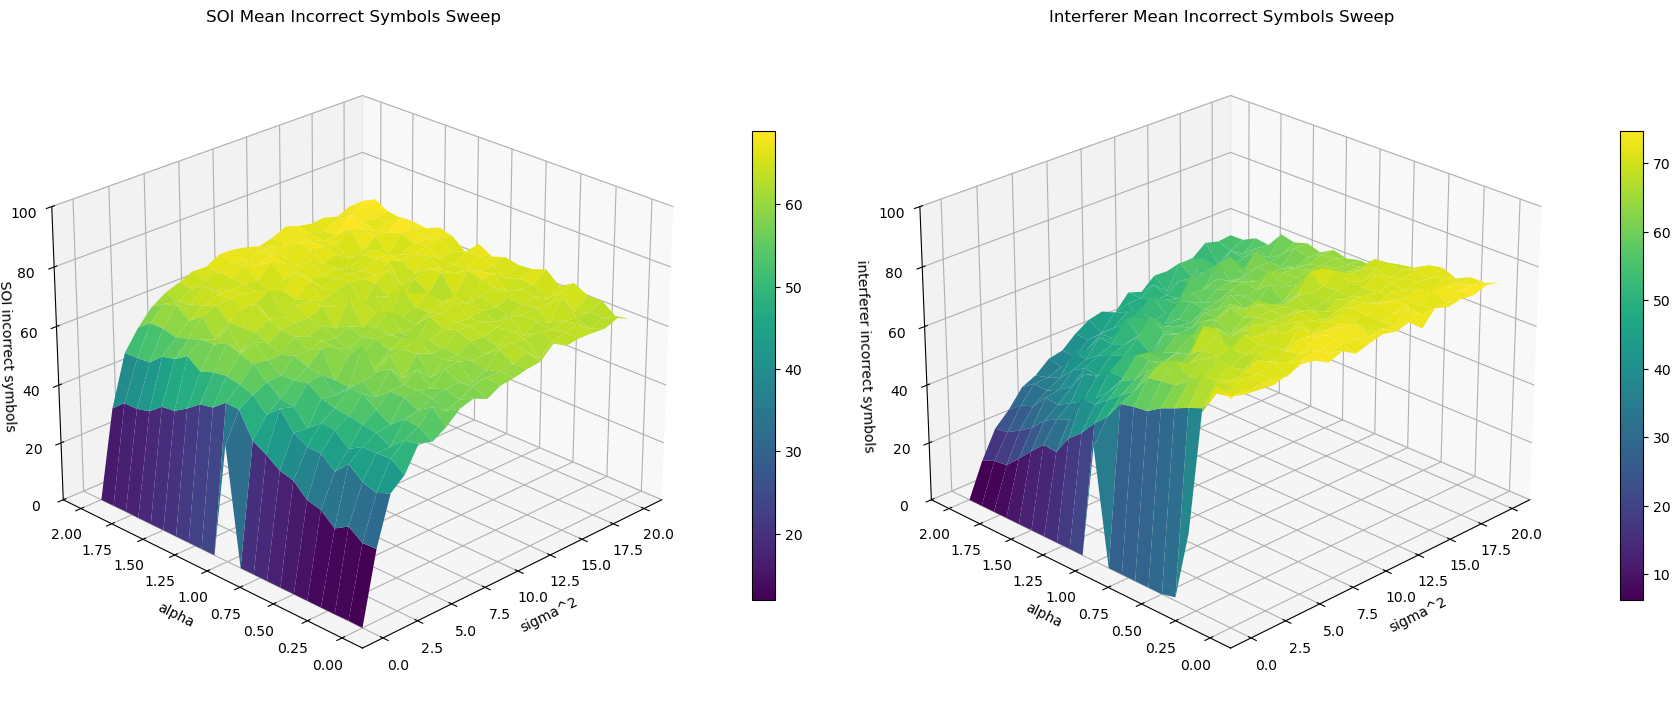

In [6]:
fig = plt.figure(figsize=(18, 7))
sigma2_grid_soi, alpha_grid_soi = np.meshgrid(
    T_a_mean_soi.columns.to_numpy(dtype=float),
    T_a_mean_soi.index.to_numpy(dtype=float),
)
z_grid_soi = (100-T_a_mean_soi).to_numpy(dtype=float)

ax1 = fig.add_subplot(121, projection="3d")
surf1 = ax1.plot_surface(sigma2_grid_soi, alpha_grid_soi, z_grid_soi, cmap="viridis", edgecolor="none")
ax1.set_xlabel("sigma^2")
ax1.set_ylabel("alpha")
ax1.set_zlabel("SOI incorrect symbols", labelpad=0)
ax1.set_zlim(0, 100)
ax1.set_title("SOI Mean Incorrect Symbols Sweep")
ax1.view_init(elev=25, azim=225)
fig.colorbar(surf1, ax=ax1, shrink=0.7, pad=0.07)

sigma2_grid_int, alpha_grid_int = np.meshgrid(
    T_a_mean_int.columns.to_numpy(dtype=float),
    T_a_mean_int.index.to_numpy(dtype=float),
)
z_grid_int = (100-T_a_mean_int).to_numpy(dtype=float)

ax2 = fig.add_subplot(122, projection="3d")
surf2 = ax2.plot_surface(sigma2_grid_int, alpha_grid_int, z_grid_int, cmap="viridis", edgecolor="none")
ax2.set_xlabel("sigma^2")
ax2.set_ylabel("alpha")
ax2.set_zlabel("interferer incorrect symbols")
ax2.set_zlim(0, 100)
ax2.set_title("Interferer Mean Incorrect Symbols Sweep")
ax2.view_init(elev=25, azim=225)
fig.colorbar(surf2, ax=ax2, shrink=0.7, pad=0.07)

plt.tight_layout()
plt.show()

#### Interpret Results

The two surface plots above represent the mean number of correctly recovered symbols for the SOI and the interferer over the alpha and sigma^2 sweep.

The tables above report the corresponding mean and variance over 10 trials for each signal separately.

As alpha increases, the interferer becomes stronger in the mixture, while increasing sigma^2 makes the additive noise more severe. Looking at the SOI and interferer surfaces separately lets us see whether one source degrades faster than the other under the same sweep conditions. Because each surface is limited to 100 symbols, the plots can be interpreted directly as source-specific symbol recovery performance.

### Experiment C

In [8]:
# Set number of receive channles
current_num_channles = 1

qpsk_cfg_soi = QPSKConfig (
    n_symbols=100,
    samples_per_symbol=2,
    rolloff=0.25,
    rrc_span_symbols=12,
    num_channels=current_num_channles
)

qpsk_cfg_int = QPSKConfig (
    n_symbols=100,
    samples_per_symbol=2,
    rolloff=0.25,
    rrc_span_symbols=12,
    num_channels=current_num_channles
)

# Start with single channel case
mix_cfg = MixtureConfig(
    alpha=0.8,
    snr_db=25,
    n_rx=current_num_channles,
    random_phase=False,
    phase_shift_deg=5
)

noise_cfg = NoiseConfig(
    enabled=True
)

# Build matched filter
rrc = rrc_taps(
    sps=2,
    beta=0.25,
    span_symbols=12
)

# thetas = np.arange(0, 2*np.pi, 0.1)
# Degree value of pi/30 is 0.1047 which is really close to 0.1 but yields cleaner restuls
thetas = np.arange(0, 2*np.pi + 0.01, np.pi/30) 
thetas_deg = np.rad2deg(thetas)
all_results = []

num_trials = 10

for i in range(num_trials):
    trial_results = []

    for theta in thetas:
        mix_cfg.interference_phase_shift = theta

        # generate mixture
        ex = gen.generate_mixture(qpsk_cfg_soi, qpsk_cfg_int, noise_cfg, mix_cfg)

        # Prepare input
        if mix_cfg.n_rx == 1:
            x = complex_to_2ch(ex["mixture"])
        else:
            x = complex_matrix_to_iq_channels(ex["mixture"])

        x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

        # Run model
        with torch.no_grad():
            pred = model(x_tensor).squeeze(0).cpu().numpy()
        
        # Convert outputs back to complex waveforms
        pred_a = pred[0] + 1j * pred[1]
        pred_b = pred[2] + 1j * pred[3]
        


        # Recover symbols
        rec_a = recover_symbols_from_waveform(
            pred_a, rrc, ExperimentConfig.samples_per_symbol, len(ex["symbols_a"])
        )
        rec_b = recover_symbols_from_waveform(
            pred_b, rrc, ExperimentConfig.samples_per_symbol, len(ex["symbols_b"])
        )

        true_a = ex["symbols_a"]
        true_b = ex["symbols_b"]

        # Check both assignemnts and keep the better one

        # Direct assignment
        n_aa = min(len(rec_a), len(true_a))
        n_bb = min(len(rec_b), len(true_b))

        # Swapped assignment
        n_ab = min(len(rec_a), len(true_b))
        n_ba = min(len(rec_b), len(true_a))

        # Mapping 1: (rec_a -> true_a) and (rec_b -> true_a)
        count_a_direct = np.sum(rec_a[:n_aa] == true_a[:n_aa])
        count_b_direct = np.sum(rec_b[:n_bb] == true_b[:n_bb])
        total_direct = count_a_direct + count_b_direct

        # Mapping 2: (rec_a -> true_b) and (rec_b -> true_a)
        count_a_swapped = np.sum(rec_a[:n_ab] == true_b[:n_ab])
        count_b_swapped = np.sum(rec_b[:n_ba] == true_a[:n_ba])
        total_swapped = count_a_swapped + count_b_swapped

        if total_direct >= total_swapped:
            # Store the count (0-100) for both signals
            soi_count = count_a_direct
            int_count = count_b_direct
        else:
            soi_count = count_b_swapped
            int_count = count_a_swapped

        trial_results.append((soi_count, int_count))

    all_results.append(trial_results)

all_results = np.array(all_results)  # (num_trials, num_thetas, 2)

# Extract means and variances for each signal type
mean_stats = all_results.mean(axis=0)  # Shape: (num_thetas, 2)
var_stats = all_results.var(axis=0)    # Shape: (num_thetas, 2)

mean_soi = mean_stats[:, 0]
mean_int = mean_stats[:, 1]

var_soi = var_stats[:, 0]
var_int = var_stats[:, 1]

# Print the Mean and the Variance 
print(f"{'Phase (deg)':<12} | {'SOI Mean':<10} | {'SOI Var':<10} | {'Int Mean':<10} | {'Int Var':<10}")
print("-" * 70)

# Print every 5th element to keep the console clean. Round deg values to make output cleaner
for i in range(len(thetas_deg))[::5]: 
    # Rounding to 0 decimal places for a "nice" look while maintaining 0.1 rad steps
    print(f"{round(thetas_deg[i]):12d} | {mean_soi[i]:10.2f} | {var_soi[i]:10.2f} | {mean_int[i]:10.2f} | {var_int[i]:10.2f}")


Phase (deg)  | SOI Mean   | SOI Var    | Int Mean   | Int Var   
----------------------------------------------------------------------
           0 |     100.00 |       0.00 |     100.00 |       0.00
          30 |     100.00 |       0.00 |     100.00 |       0.00
          60 |     100.00 |       0.00 |     100.00 |       0.00
          90 |      99.90 |       0.09 |      99.90 |       0.09
         120 |     100.00 |       0.00 |     100.00 |       0.00
         150 |      99.90 |       0.09 |      99.90 |       0.09
         180 |      99.90 |       0.09 |      99.90 |       0.09
         210 |     100.00 |       0.00 |     100.00 |       0.00
         240 |      99.60 |       0.44 |      99.60 |       0.44
         270 |      99.80 |       0.16 |      99.80 |       0.16
         300 |      99.50 |       0.25 |      99.40 |       0.44
         330 |      99.10 |       0.89 |      99.10 |       0.89
         360 |      99.80 |       0.16 |      99.80 |       0.16


#### Plot Results

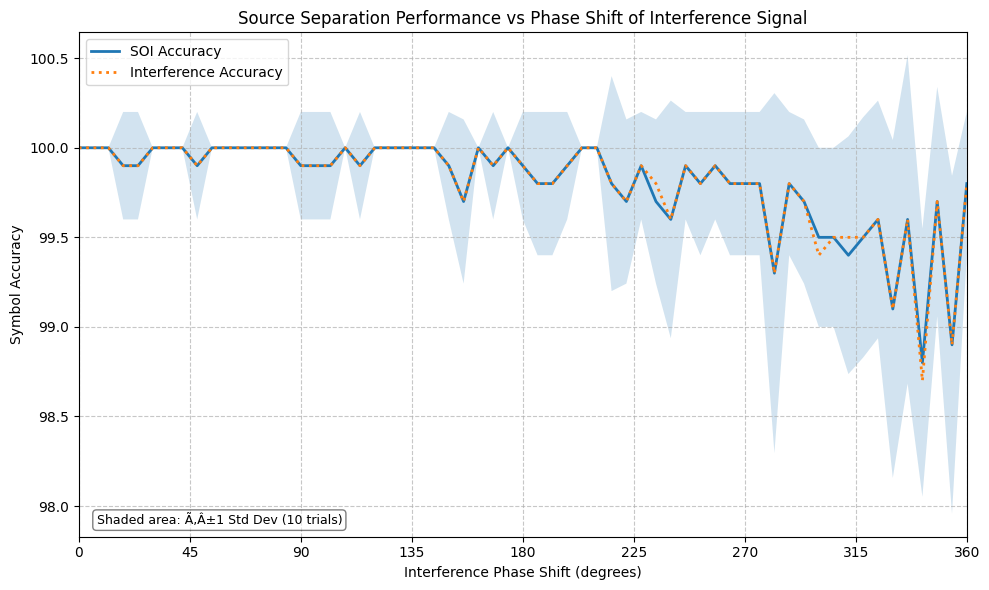

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot using the degree vector
plt.plot(thetas_deg, mean_soi, label='SOI Accuracy', linewidth=2)
plt.plot(thetas_deg, mean_int, label='Interference Accuracy', ls=':', linewidth=2)

# Fill variance (remember to use the degree vector here too)
plt.fill_between(
    thetas_deg, 
    mean_soi - np.sqrt(var_soi), 
    mean_soi + np.sqrt(var_soi), 
    alpha=0.2
)

# Set the x-axis to standard degree increments
plt.xticks(np.arange(0, 361, 45)) 
plt.xlim(0, 360)

plt.xlabel('Interference Phase Shift (degrees)')
plt.ylabel('Symbol Accuracy')
plt.title('Source Separation Performance vs Phase Shift of Interference Signal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('phase_sweep_results.png') 

# Add the note using transform=ax.transAxes to keep it in the corner without resizing the plot
ax = plt.gca()
ax.text(0.02, 0.02, 'Shaded area: Ã‚Â±1 Std Dev (10 trials)', 
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.show()

#### Interpret Results

The line in the above plot represents the mean symbol accuracy over phase shifts.

The blue fill region represents the standard deviation 

When the config file has noise_enabled = False symbol accuracy is 100% for all interference phase shifts. When the noise is enabled we still get above 98% for all phase shifts. This tells us the the changes that we see in symbol accuracy are more because of the random generation of the noise then the phase shift.

### Experiment D

In [10]:
# Set number of receive channles
current_num_channles = 1

# fs = samples per symbol for this experiment
#fs_values = np.array([1] + list(range(10, 101, 10)))
fs_values = np.array([1, 2] + list(range(10, 101, 10)))
all_results = []

num_trials = 10

for i in range(num_trials):
    trial_results = []

    for fs in fs_values:
        qpsk_cfg_soi = QPSKConfig (
            n_symbols=100,
            samples_per_symbol=fs,
            rolloff=0.25,
            rrc_span_symbols=12,
            num_channels=current_num_channles
        )

        qpsk_cfg_int = QPSKConfig (
            n_symbols=100,
            samples_per_symbol=fs,
            rolloff=0.25,
            rrc_span_symbols=12,
            num_channels=current_num_channles
        )

        # Start with single channel case
        mix_cfg = MixtureConfig(
            alpha=0.8,
            snr_db=25,
            n_rx=current_num_channles,
            random_phase=False,
            phase_shift_deg=5
        )

        noise_cfg = NoiseConfig(
            enabled=True
        )

        # Build matched filter
        rrc = rrc_taps(
            sps=fs,
            beta=0.25,
            span_symbols=12
        )

        # generate mixture
        ex = gen.generate_mixture(qpsk_cfg_soi, qpsk_cfg_int, noise_cfg, mix_cfg)

        # Prepare input
        if mix_cfg.n_rx == 1:
            x = complex_to_2ch(ex["mixture"])
        else:
            x = complex_matrix_to_iq_channels(ex["mixture"])

        x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

        # Run model
        with torch.no_grad():
            pred = model(x_tensor).squeeze(0).cpu().numpy()
        
        # Convert outputs back to complex waveforms
        pred_a = pred[0] + 1j * pred[1]
        pred_b = pred[2] + 1j * pred[3]
        

        # Recover symbols
        rec_a = recover_symbols_from_waveform(
            pred_a, rrc, fs, len(ex["symbols_a"])
        )
        rec_b = recover_symbols_from_waveform(
            pred_b, rrc, fs, len(ex["symbols_b"])
        )

        true_a = ex["symbols_a"]
        true_b = ex["symbols_b"]

        # Check both assignemnts and keep the better one

        # Direct assignment
        n_aa = min(len(rec_a), len(true_a))
        n_bb = min(len(rec_b), len(true_b))

        # Swapped assignment
        n_ab = min(len(rec_a), len(true_b))
        n_ba = min(len(rec_b), len(true_a))

        # Mapping 1: (rec_a -> true_a) and (rec_b -> true_a)
        count_a_direct = np.sum(rec_a[:n_aa] == true_a[:n_aa])
        count_b_direct = np.sum(rec_b[:n_bb] == true_b[:n_bb])
        total_direct = count_a_direct + count_b_direct

        # Mapping 2: (rec_a -> true_b) and (rec_b -> true_a)
        count_a_swapped = np.sum(rec_a[:n_ab] == true_b[:n_ab])
        count_b_swapped = np.sum(rec_b[:n_ba] == true_a[:n_ba])
        total_swapped = count_a_swapped + count_b_swapped

        if total_direct >= total_swapped:
            # Store the count (0-1) for both signals
            soi_count = count_a_direct
            int_count = count_b_direct
        else:
            soi_count = count_b_swapped
            int_count = count_a_swapped

        trial_results.append((soi_count, int_count))

    all_results.append(trial_results)

all_results = np.array(all_results)  # (num_trials, num_fs, 2)

# Extract means and variances for each signal type
mean_stats = all_results.mean(axis=0)  # Shape: (num_fs, 2)
var_stats = all_results.var(axis=0)    # Shape: (num_fs, 2)

mean_soi = mean_stats[:, 0]
mean_int = mean_stats[:, 1]

var_soi = var_stats[:, 0]
var_int = var_stats[:, 1]

# Print the Mean and the Variance 
print(f"{'fs':<12} | {'SOI Mean':<10} | {'SOI Var':<10} | {'Int Mean':<10} | {'Int Var':<10}")
print("-" * 70)

# Print every element since there are only a few fs values
for i in range(len(fs_values)): 
    print(f"{fs_values[i]:12d} | {mean_soi[i]:10.2f} | {var_soi[i]:10.2f} | {mean_int[i]:10.2f} | {var_int[i]:10.2f}")

fs           | SOI Mean   | SOI Var    | Int Mean   | Int Var   
----------------------------------------------------------------------
           1 |      52.10 |      17.29 |      43.70 |      36.21
           2 |     100.00 |       0.00 |     100.00 |       0.00
          10 |      92.30 |      12.41 |      77.20 |      21.76
          20 |      90.50 |       5.45 |      76.30 |      16.01
          30 |      89.90 |      17.09 |      76.20 |      35.96
          40 |      90.80 |       2.56 |      76.30 |      11.81
          50 |      91.30 |       6.41 |      74.60 |       8.64
          60 |      89.90 |       3.29 |      74.00 |      18.00
          70 |      90.10 |       6.49 |      74.90 |      12.69
          80 |      89.20 |       2.36 |      74.00 |      27.80
          90 |      91.90 |       7.69 |      75.80 |      11.56
         100 |      91.10 |       2.89 |      75.40 |       9.64


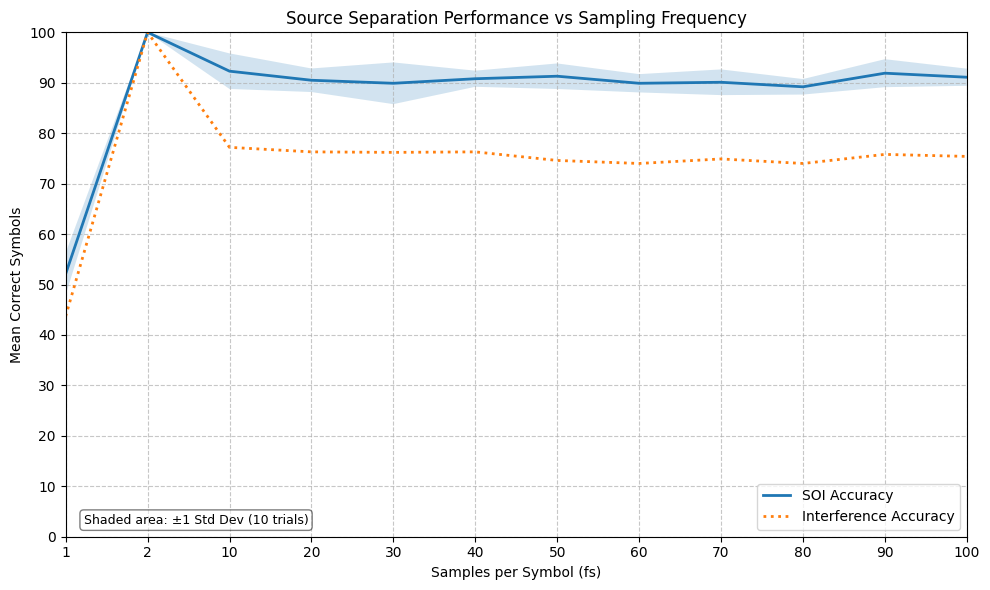

In [11]:
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(10, 6))

# # Plot using the fs vector
# plt.plot(fs_values, mean_soi, label='SOI Accuracy', linewidth=2)
# plt.plot(fs_values, mean_int, label='Interference Accuracy', ls=':', linewidth=2)

# # Fill variance (remember to use the fs vector here too)
# plt.fill_between(
    # fs_values, 
    # mean_soi - np.sqrt(var_soi), 
    # mean_soi + np.sqrt(var_soi), 
    # alpha=0.2
# )

# # Set the x-axis to standard fs increments
# plt.xticks(fs_values) 
# plt.xlim(fs_values[0], fs_values[-1])

# plt.xlabel('Samples per Symbol (fs)')
# plt.ylabel('Mean Correct Symbols')
# plt.ylim(0, 100)
# plt.title('Source Separation Performance vs Sampling Frequency')
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# # plt.savefig('fs_sweep_results.png') 

# # Add the note using transform=ax.transAxes to keep it in the corner without resizing the plot
# ax = plt.gca()
# ax.text(0.02, 0.02, 'Shaded area: Â±1 Std Dev (10 trials)', 
        # transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        # bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
# plt.show()

import matplotlib.pyplot as plt
import numpy as np

# Use evenly spaced positions for plotting
x_pos = np.arange(len(fs_values))

plt.figure(figsize=(10, 6))

# Plot using evenly spaced x positions
plt.plot(x_pos, mean_soi, label='SOI Accuracy', linewidth=2)
plt.plot(x_pos, mean_int, label='Interference Accuracy', ls=':', linewidth=2)

# Fill variance (remember to use the x positions here too)
plt.fill_between(
    x_pos,
    mean_soi - np.sqrt(var_soi),
    mean_soi + np.sqrt(var_soi),
    alpha=0.2
)

# Show the real fs values as labels
plt.xticks(x_pos, fs_values)
plt.xlim(x_pos[0], x_pos[-1])

plt.xlabel('Samples per Symbol (fs)')
plt.ylabel('Mean Correct Symbols')
plt.title('Source Separation Performance vs Sampling Frequency')
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 10))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('fs_sweep_results.png')

# Add the note using transform=ax.transAxes to keep it in the corner without resizing the plot
ax = plt.gca()
ax.text(0.02, 0.02, 'Shaded area: ±1 Std Dev (10 trials)',
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.show()

#### Interpret Results

The line in the above plot represents the mean symbol accuracy.

The blue fill region represents the standard deviation 

This plot shows us that the number of symbols (spatial information) is critically important. Because the model was training on symbol sequences of size 100 and a sampling frequency of 2, reducing the symbol size hurts preformance drastically. If we sample either signal more than the sampling frequency that the network was trained on we don't keep our good preformance. It drops from 2->10 and then seems to plateau. This suggests that a higher sampling frequency isn't always better.

We also don't work with carrier frequency so this experiment is a little outdated

#### Experiment E

In [12]:
# Set number of receive channles
current_num_channles = 1

# T1 and T2 values for this experiment
T_values = np.arange(0.1, 2.0 + 0.01, 0.1)

# Map T values to integer samples per symbol
# Example: 0.1 -> 1, 0.2 -> 2, ..., 2.0 -> 20
sps_values = (T_values * 10).astype(int)

mean_table_soi = np.zeros((len(T_values), len(T_values)))
var_table_soi = np.zeros((len(T_values), len(T_values)))

mean_table_int = np.zeros((len(T_values), len(T_values)))
var_table_int = np.zeros((len(T_values), len(T_values)))

num_trials = 10

for t1_idx, sps_soi in enumerate(sps_values):
    for t2_idx, sps_int in enumerate(sps_values):
        all_results = []

        for i in range(num_trials):
            qpsk_cfg_soi = QPSKConfig (
                n_symbols=100,
                samples_per_symbol=sps_soi,
                rolloff=0.25,
                rrc_span_symbols=12,
                num_channels=current_num_channles
            )

            qpsk_cfg_int = QPSKConfig (
                n_symbols=100,
                samples_per_symbol=sps_int,
                rolloff=0.25,
                rrc_span_symbols=12,
                num_channels=current_num_channles
            )

            # Start with single channel case
            mix_cfg = MixtureConfig(
                alpha=0.8,
                snr_db=25,
                n_rx=current_num_channles,
                random_phase=False,
                phase_shift_deg=5
            )

            noise_cfg = NoiseConfig(
                enabled=True
            )

            # Build matched filter
            rrc_soi = rrc_taps(
                sps=sps_soi,
                beta=0.25,
                span_symbols=12
            )

            rrc_int = rrc_taps(
                sps=sps_int,
                beta=0.25,
                span_symbols=12
            )

            # generate mixture
            ex = gen.generate_mixture(qpsk_cfg_soi, qpsk_cfg_int, noise_cfg, mix_cfg)

            # Prepare input
            if mix_cfg.n_rx == 1:
                x = complex_to_2ch(ex["mixture"])
            else:
                x = complex_matrix_to_iq_channels(ex["mixture"])

            x_tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

            # Run model
            with torch.no_grad():
                pred = model(x_tensor).squeeze(0).cpu().numpy()
            
            # Convert outputs back to complex waveforms
            pred_a = pred[0] + 1j * pred[1]
            pred_b = pred[2] + 1j * pred[3]
            

            # Recover symbols
            rec_a_soi = recover_symbols_from_waveform(
                pred_a, rrc_soi, sps_soi, len(ex["symbols_a"])
            )
            rec_b_int = recover_symbols_from_waveform(
                pred_b, rrc_int, sps_int, len(ex["symbols_b"])
            )

            rec_a_int = recover_symbols_from_waveform(
                pred_a, rrc_int, sps_int, len(ex["symbols_b"])
            )
            rec_b_soi = recover_symbols_from_waveform(
                pred_b, rrc_soi, sps_soi, len(ex["symbols_a"])
            )

            true_a = ex["symbols_a"]
            true_b = ex["symbols_b"]

            # Check both assignemnts and keep the better one

            # Direct assignment
            n_aa = min(len(rec_a_soi), len(true_a))
            n_bb = min(len(rec_b_int), len(true_b))

            # Swapped assignment
            n_ab = min(len(rec_a_int), len(true_b))
            n_ba = min(len(rec_b_soi), len(true_a))

            # Mapping 1: (rec_a -> true_a) and (rec_b -> true_b)
            count_a_direct = np.sum(rec_a_soi[:n_aa] == true_a[:n_aa])
            count_b_direct = np.sum(rec_b_int[:n_bb] == true_b[:n_bb])
            total_direct = count_a_direct + count_b_direct

            # Mapping 2: (rec_a -> true_b) and (rec_b -> true_a)
            count_a_swapped = np.sum(rec_a_int[:n_ab] == true_b[:n_ab])
            count_b_swapped = np.sum(rec_b_soi[:n_ba] == true_a[:n_ba])
            total_swapped = count_a_swapped + count_b_swapped

            if total_direct >= total_swapped:
                # Store the count (0-100) for both signals
                soi_count = count_a_direct
                int_count = count_b_direct
            else:
                soi_count = count_b_swapped
                int_count = count_a_swapped

            all_results.append((soi_count, int_count))

        all_results = np.array(all_results)  # (num_trials, 2)

        # Extract means and variances for each signal type
        mean_stats = all_results.mean(axis=0)  # Shape: (2,)
        var_stats = all_results.var(axis=0)    # Shape: (2,)

        mean_table_soi[t1_idx, t2_idx] = mean_stats[0]
        var_table_soi[t1_idx, t2_idx] = var_stats[0]

        mean_table_int[t1_idx, t2_idx] = mean_stats[1]
        var_table_int[t1_idx, t2_idx] = var_stats[1]

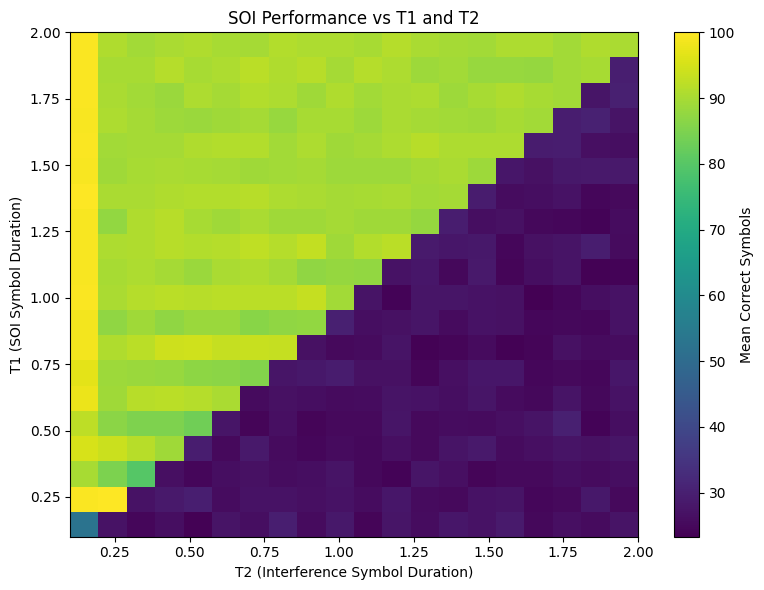

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

im = plt.imshow(
    mean_table_soi,
    origin='lower',
    aspect='auto',
    extent=[T_values[0], T_values[-1], T_values[0], T_values[-1]]
)

plt.colorbar(im, label='Mean Correct Symbols')

plt.xlabel('T2 (Interference Symbol Duration)')
plt.ylabel('T1 (SOI Symbol Duration)')
plt.title('SOI Performance vs T1 and T2')

plt.grid(False)
plt.tight_layout()
plt.show()

#### Interpret Results

The system exhibits clear assymetry when comparing symbol durations. Whenever our signal of interest has a higher sampling rate the model gets a very high symbol recovery. When the interference signal has a higher sampling rate the model gets very poor symbol recovery.

The observed asymmetry is not due to increased sampling resolution alone, but rather due to the relative symbol durations of the sources. When the SOI has a larger symbol duration than the interferer, the interferer behaves as a higher-frequency component that is attenuated by the matched filter, enabling accurate recovery. Conversely, when the interferer has a larger symbol duration, it behaves as a low-frequency component that cannot be suppressed by the SOI-matched filter, leading to poor recovery. This indicates that the separator is exploiting temporal scale differences rather than performing true source separation.
